# **Automatización de Análisis y Visualización de Datos Climáticos**

**asignatura:** Bases de programación.

**Integrantes:**
- Joyce Bermúdez Cajiao
- Angie Pincay Velasquez

---

## **Introducción**

El monitoreo climático genera grandes volúmenes de información que deben procesarse de forma rápida, consistente y reproducible. Hacerlo manualmente, ciudad por ciudad o variable por variable, es lento y propenso a errores.

El análisis de datos climáticos es una herramienta fundamental para comprender el comportamiento de variables atmosféricas como la temperatura, la humedad, la precipitación y la velocidad del viento, las cuales permiten identificar patrones, tendencias y anomalías relevantes para la investigación científica y la toma de decisiones (IPCC, 2023).

La automatización mediante funciones y bucles permitió desarrollar un flujo de trabajo capaz de cargar, procesar y analizar automáticamente la base de datos climática. Además, se implementaron procedimientos para validar y limpiar los datos, calcular indicadores estadísticos y generar visualizaciones, reduciendo la intervención manual, mejorando la eficiencia del análisis y favoreciendo la reutilización del código en futuros conjuntos de datos (McKinney, 2022; VanderPlas, 2016).



## **Objetivo**

Automatizar el proceso de carga, limpieza, análisis exploratorio y visualización de un conjunto de datos climáticos correspondientes a diez ciudades de Estados Unidos, mediante el uso de estructuras de control, funciones y bucles en Python. Esto permite que el mismo flujo de trabajo pueda reutilizarse fácilmente si se agregan nuevas ciudades, variables o periodos de tiempo, mejorando la eficiencia y la reproducibilidad del análisis.

El desarrollo se organiza en cuatro etapas, siguiendo la estructura del proyecto:

1. Carga y preparación de datos.
2. Automatización del análisis exploratorio de datos (EDA).
3. Manipulación de datos con Pandas.
4. Visualización automatizada de datos.

## 1. Carga y preparación de datos

### 1.1 Importación de librerías

In [1]:
# Se importa la librería Pandas y se le asigna el alias pd.
# Uso: cargar, limpiar y analizar datos en tablas llamadas DataFrame.
import pandas as pd

# Se importa la librería NumPy con el alias np.
# Uso: trabajar con operaciones numéricas y arreglos de datos.
import numpy as np

# Se importa Matplotlib con el alias plt.
# Uso: crear y guardar gráficos.
import matplotlib.pyplot as plt


### 1.2 Función de carga de datos

Cargar el conjunto de datos utilizando pandas.


In [2]:
# Función para cargar datos
def cargar_datos(file_name):
    datos = pd.read_csv(file_name)
    return datos

# Nombre del archivo CSV
file = "Weather_Data-1.csv"

# Cargar la base de datos
df = cargar_datos(file)

# Mostrar las primeras filas
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,1/14/2024 21:12,10.683001,41.195754,4.020119,8.233540
1,San Diego,5/17/2024 15:22,8.734140,58.319107,9.111623,27.715161
2,San Diego,5/11/2024 9:30,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2/26/2024 17:32,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,4/29/2024 13:23,39.808213,72.899908,9.598282,29.898622


### 1.3 Descripción del conjunto de datos

El conjunto de datos **Weather_Data-1.csv** contiene observaciones climáticas para **10 ciudades de Estados Unidos** (San Diego, Los Ángeles, San José, Phoenix, San Antonio, Houston, Dallas, Chicago, Filadelfia y Nueva York), registradas entre **enero y mayo de 2024**, con marcas de tiempo distribuidas a lo largo del día.

| Columna | Descripción | Unidad |
|---|---|---|
| `Location` | Ciudad de la observación | — |
| `Date_Time` | Fecha y hora del registro | — |
| `Temperature_C` | Temperatura del aire | °C |
| `Humidity_pct` | Humedad relativa | % |
| `Precipitation_mm` | Precipitación acumulada | mm |
| `Wind_Speed_kmh` | Velocidad del viento | km/h |

El archivo contiene **1,000,000 de registros**, lo que permite practicar técnicas de manipulación de datos a una escala realista.

In [3]:
# Tamaño de la base de datos
print(f"El número de filas y columnas de la base de datos climáticos es: {df.shape}")

# Mostrar las primeras filas
df.head()

El número de filas y columnas de la base de datos climáticos es: (1000000, 6)


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,1/14/2024 21:12,10.683001,41.195754,4.020119,8.233540
1,San Diego,5/17/2024 15:22,8.734140,58.319107,9.111623,27.715161
2,San Diego,5/11/2024 9:30,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2/26/2024 17:32,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,4/29/2024 13:23,39.808213,72.899908,9.598282,29.898622


In [4]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  str    
 1   Date_Time         1000000 non-null  str    
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), str(2)
memory usage: 45.8 MB


**Nota:** Se utiliza el método info() de Pandas para obtener información general del DataFrame, como el número de filas y columnas, los nombres de las variables, la cantidad de valores no nulos y el tipo de dato de cada columna. Esto permite verificar la estructura del conjunto de datos antes de iniciar el análisis.

### 1.4 Revisión y limpieza de datos
Realizar limpieza básica de datos, eliminando duplicados y modificando los tipos de datos en caso de ser necesario.

<span style="color:#0bbdae;"><b>**Revisión inicial**</b></span>

 1. Se crea una función que utiliza los métodos isnull() y sum() para contar la cantidad de valores nulos en cada columna del DataFrame. Finalmente, se muestran los resultados en pantalla.
 3. Se crea una función que utiliza el método duplicated() para identificar las filas repetidas y sum() para contar el total de registros duplicados. Luego, se imprime el resultado en pantalla.

In [5]:
# 2.3 Revisión inicial de la base de datos

# Ver cantidad de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Ver cantidad de filas duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
Location            0
Date_Time           0
Temperature_C       0
Humidity_pct        0
Precipitation_mm    0
Wind_Speed_kmh      0
dtype: int64
Filas duplicadas: 0


 <span style="color:#0bbdae;"><b>**Limpieza inicial de datos**</b></span>

In [6]:
# Función para eliminar filas duplicadas

def eliminar_duplicados(datos):
    filas_antes = datos.shape[0]
    datos = datos.drop_duplicates()
    filas_despues = datos.shape[0]

    print("Filas antes:", filas_antes)
    print("Filas después:", filas_despues)
    print("Filas duplicadas eliminadas:", filas_antes - filas_despues)

    return datos

# Aplicar la función
df = eliminar_duplicados(df)

Filas antes: 1000000
Filas después: 1000000
Filas duplicadas eliminadas: 0


<span style="color:#0bbdae;"><b>**Validación de inconsistencias**</b></span>

**Revisar espacios en blanco al inicio o al final:**
Se crea una función que compara los valores originales de la columna con los mismos valores después de eliminar los espacios al inicio y al final mediante str.strip(). Si existen diferencias, se muestran las filas con posibles inconsistencias.

In [7]:
# Función para revisar espacios en blanco
def revisar_espacios(datos, columna):
    return datos[datos[columna] != datos[columna].str.strip()]

print("Filas con espacios al inicio o al final:")
display(revisar_espacios(df, "Location"))

Filas con espacios al inicio o al final:


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh


**Revisión de valores vacíos:**
Se verifica si la columna **Location** contiene cadenas vacías (""), las cuales representan registros sin información. Si el resultado es cero, significa que no existen valores vacíos en la columna.

In [8]:
print("Valores vacíos en Location:")
print((df["Location"] == "").sum())

Valores vacíos en Location:
0


**Revisión de espacios dobles:**
Se verifica si existen espacios dobles dentro de los nombres de las ciudades utilizando el método str.contains(). Si el resultado es cero, se confirma que los registros no presentan este tipo de inconsistencia.

In [9]:
print("Espacios dobles en Location:")
print(df["Location"].str.contains("  ").sum())

Espacios dobles en Location:
0


**Validación de caracteres no numéricos:**
Se verifica que las columnas numéricas únicamente contengan valores numéricos. Para ello, se utiliza `pd.to_numeric()` con el parámetro `errors="coerce"`, el cual convierte en valores nulos (`NaN`) cualquier dato que contenga letras o símbolos. Finalmente, se cuenta el número de inconsistencias encontradas en cada variable.

In [10]:
# Función para verificar caracteres no numéricos
def revisar_numericos(datos, columnas):
    for columna in columnas:
        inconsistencias = pd.to_numeric(
            datos[columna], errors="coerce"
        ).isnull().sum()

        print(f"{columna}: {inconsistencias} inconsistencias")

columnas_numericas = [
    "Temperature_C",
    "Humidity_pct",
    "Precipitation_mm",
    "Wind_Speed_kmh"
]

revisar_numericos(df, columnas_numericas)

Temperature_C: 0 inconsistencias
Humidity_pct: 0 inconsistencias
Precipitation_mm: 0 inconsistencias
Wind_Speed_kmh: 0 inconsistencias


**Validación de caracteres en columnas de texto:** Se verifica que la columna **Location** únicamente contenga letras y espacios. Si se detectan números o símbolos especiales, estos se consideran posibles inconsistencias en los datos.

In [11]:
# Revisar nombres diferentes a los esperados
ciudades_validas = [
    "New York",
    "Los Angeles",
    "Chicago",
    "Houston",
    "Phoenix",
    "Philadelphia",
    "San Antonio",
    "San Diego",
    "Dallas",
    "San Jose"
]

display(df[~df["Location"].isin(ciudades_validas)])

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh


### 1.5 Resumen estadístico

Se utiliza el método **describe()** de Pandas para obtener un resumen estadístico de las variables numéricas y de fecha del conjunto de datos. Este resumen presenta medidas descriptivas como el número de registros (count), la media (mean), el valor mínimo (min), los cuartiles (25 %, 50 % y 75 %), el valor máximo (max) y la desviación estándar (std). Estos indicadores permiten conocer la distribución de los datos, identificar su rango de variación y comprender el comportamiento general de las variables climáticas antes de realizar análisis más específicos.

In [12]:
# Resumen estadístico
df.describe()

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


## 2. Automatización del análisis exploratorio de datos (EDA)


### 2.1 Estructuras de datos para almacenar información relevante

Se crea una lista para almacenar las **variables numéricas** que serán utilizadas durante el análisis exploratorio y un **diccionario** que relaciona cada variable con su respectiva descripción. Posteriormente, mediante un bucle `for` se recorren estas estructuras para mostrar la información almacenada, facilitando la organización y automatización del análisis.

In [13]:
# Lista con variables numéricas del dataset
columnas_numericas = [
    "Temperature_C",
    "Humidity_pct",
    "Precipitation_mm",
    "Wind_Speed_kmh"
]

# Diccionario con descripción de las variables
descripcion_variables = {
    "Temperature_C": "Temperatura en grados Celsius",
    "Humidity_pct": "Humedad relativa en porcentaje",
    "Precipitation_mm": "Precipitación en milímetros",
    "Wind_Speed_kmh": "Velocidad del viento en km/h"
}

# Mostrar variables seleccionadas
for columna in columnas_numericas:
    print(columna, ":", descripcion_variables[columna])

Temperature_C : Temperatura en grados Celsius
Humidity_pct : Humedad relativa en porcentaje
Precipitation_mm : Precipitación en milímetros
Wind_Speed_kmh : Velocidad del viento en km/h


### 2.2 Función para estadísticas descriptivas
Se implementa una función que calcula automáticamente la media, la mediana y la desviación estándar de las variables numéricas del conjunto de datos. Los resultados se almacenan en un diccionario para facilitar su consulta y reutilización durante el análisis exploratorio.

In [14]:
# Función para calcular estadísticas descriptivas
def estadisticas_descriptivas(datos, columnas):

    resultados = {}

    for columna in columnas:

        resultados[columna] = {
            "Media": datos[columna].mean(),
            "Mediana": datos[columna].median(),
            "Desviación estándar": datos[columna].std()
        }

    # Convertir el diccionario en una tabla
    tabla = pd.DataFrame(resultados).T

    # Redondear a dos decimales
    return tabla.round(2)

# Aplicar la función
tabla_estadisticas = estadisticas_descriptivas(df, columnas_numericas)

# Mostrar la tabla
display(tabla_estadisticas)

,Media,Mediana,Desviación estándar
Temperature_C,14.78,14.78,14.48
Humidity_pct,60.02,60.02,17.32
Precipitation_mm,5.11,5.11,2.95
Wind_Speed_kmh,15.00,14.99,8.66


### 2.3 Promedio de variables climáticas por ciudad
Se agrupan los registros por ciudad mediante el método `groupby()` y se calcula el valor promedio de las principales variables climáticas utilizando `mean()`. Posteriormente, se presentan los resultados en una tabla resumen que permite comparar el comportamiento promedio de la temperatura, humedad, precipitación y velocidad del viento entre las diferentes ciudades del conjunto de datos.

In [15]:
# Calcular el promedio de las variables climáticas por ciudad
promedio_ciudad = df.groupby("Location")[[
    "Temperature_C",
    "Humidity_pct",
    "Precipitation_mm",
    "Wind_Speed_kmh"
]].mean()

# Redondear a dos decimales
promedio_ciudad = promedio_ciudad.round(2)

# Mostrar la tabla
display(promedio_ciudad)

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
Location,,,,
Chicago,15.01,60.09,5.00,15.00
Dallas,15.01,59.96,5.00,15.02
Houston,14.94,59.97,5.00,14.99
Los Angeles,15.08,60.07,5.00,15.04
New York,15.01,60.04,4.99,14.99
Philadelphia,15.04,60.04,5.01,14.99
Phoenix,12.79,60.05,6.09,14.98
San Antonio,15.03,59.93,5.01,14.96
San Diego,14.93,60.07,5.01,15.04


## 3. Manipulación de datos con Pandas

En esta sección se continúa el análisis utilizando funciones, agrupamientos, filtros avanzados y columnas derivadas. El objetivo es transformar el DataFrame original en una base más completa para el análisis climático.


### 3.1 Conversión de fecha y creación de columnas temporales

Se convierte la columna **Date_Time** a formato de fecha con **pd.to_datetime()**. Luego se crean nuevas columnas para separar el año, el mes, el día y la hora. Esto facilita los análisis por periodo de tiempo.


In [16]:
# Convertir la columna Date_Time a tipo fecha
# errors="coerce" convierte fechas inválidas en NaT, evitando que el código se detenga.
df["Date_Time"] = pd.to_datetime(df["Date_Time"], errors="coerce")

# Crear columnas derivadas de la fecha
df["Anio"] = df["Date_Time"].dt.year
df["Mes"] = df["Date_Time"].dt.month
df["Dia"] = df["Date_Time"].dt.day
df["Hora"] = df["Date_Time"].dt.hour

# Verificar las nuevas columnas creadas
display(df[["Date_Time", "Anio", "Mes", "Dia", "Hora"]].head())


,Date_Time,Anio,Mes,Dia,Hora
0,2024-01-14 21:12:00,2024,1,14,21
1,2024-05-17 15:22:00,2024,5,17,15
2,2024-05-11 09:30:00,2024,5,11,9
3,2024-02-26 17:32:00,2024,2,26,17
4,2024-04-29 13:23:00,2024,4,29,13


### 3.2 Columna derivada: sensación térmica

Se crea una nueva columna calculando la **sensación térmica** (temperatura aparente) a partir de la temperatura, la humedad y el viento, usando la fórmula de temperatura aparente de Steadman (1994), adoptada por la Oficina de Meteorología de Australia:

$$AT = T_a + 0.33e - 0.70v - 4.00$$

donde $T_a$ es la temperatura del aire (°C), $v$ es la velocidad del viento (m/s) y $e$ es la presión de vapor (hPa), calculada como:

$$e = \frac{HR}{100} \times 6.105 \times e^{\frac{17.27\, T_a}{237.7 + T_a}}$$


In [17]:
# Función para calcular la sensación térmica aproximada
def calcular_sensacion_termica(temp_c, humedad_pct, viento_kmh):
    '''Calcula la sensación térmica (°C) a partir de temperatura, humedad y viento.'''
    viento_ms = viento_kmh / 3.6
    presion_vapor = (humedad_pct / 100) * 6.105 * np.exp((17.27 * temp_c) / (237.7 + temp_c))
    return temp_c + 0.33 * presion_vapor - 0.70 * viento_ms - 4.00


df['Sensacion_Termica'] = calcular_sensacion_termica(
    df['Temperature_C'], df['Humidity_pct'], df['Wind_Speed_kmh']
)

diferencia_promedio = (df['Sensacion_Termica'] - df['Temperature_C']).mean()
print(f'Diferencia promedio (sensación térmica − temperatura real): {diferencia_promedio:+.2f} °C')
df[['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Sensacion_Termica']].head()

Diferencia promedio (sensación térmica − temperatura real): -2.25 °C


,Location,Date_Time,Temperature_C,Humidity_pct,Wind_Speed_kmh,Sensacion_Termica
0,San Diego,2024-01-14 21:12:00,10.683001,41.195754,8.233540,6.826410
1,San Diego,2024-05-17 15:22:00,8.734140,58.319107,27.715161,1.511964
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,28.732951,3.796033
3,Philadelphia,2024-02-26 17:32:00,-8.628976,54.074474,26.367303,-17.187542
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,29.898622,47.486231


### 3.3 Creación de una columna categórica

Se crea la columna **Categoria_Temperatura** para clasificar cada registro según su temperatura. Esta clasificación permite resumir mejor el comportamiento térmico del conjunto de datos.


In [18]:
# Función para clasificar la temperatura
def clasificar_temperatura(temperatura):
    if temperatura < 0:
        return "Muy fria"
    elif temperatura < 10:
        return "Fria"
    elif temperatura < 20:
        return "Templada"
    elif temperatura < 30:
        return "Calida"
    else:
        return "Muy calida"

# Crear la columna categórica usando apply()
df["Categoria_Temperatura"] = df["Temperature_C"].apply(clasificar_temperatura)

# Verificar la cantidad de registros por categoría
print("Cantidad de registros por categoría de temperatura:")
print(df["Categoria_Temperatura"].value_counts())


Cantidad de registros por categoría de temperatura:
Categoria_Temperatura
Muy fria      204547
Calida        201162
Fria          199904
Templada      199467
Muy calida    194920
Name: count, dtype: int64


### 3.4 Función de agrupamiento y agregación

Se crea una función que permite agrupar los datos por una columna y aplicar operaciones estadísticas como promedio, mínimo, máximo y desviación estándar. Esta función evita repetir código y permite automatizar el análisis.


In [19]:
# Función para agrupar y agregar datos
def agrupar_y_agregar(datos, columna_grupo, columnas_valor, operaciones):
    resumen = datos.groupby(columna_grupo)[columnas_valor].agg(operaciones)
    return resumen.round(2)

# Aplicar la función agrupando por ciudad
resumen_por_ciudad = agrupar_y_agregar(
    df,
    "Location",
    columnas_numericas,
    ["mean", "min", "max", "std"]
)

# Mostrar el resumen por ciudad
display(resumen_por_ciudad)


Temperature_C                     Humidity_pct              \
                      mean    min   max    std         mean   min   max   
Location                                                                  
Chicago              15.01 -10.00  40.0  14.44        60.09  30.0  90.0   
Dallas               15.01 -10.00  40.0  14.46        59.96  30.0  90.0   
Houston              14.94 -10.00  40.0  14.44        59.97  30.0  90.0   
Los Angeles          15.08 -10.00  40.0  14.48        60.07  30.0  90.0   
New York             15.01 -10.00  40.0  14.41        60.04  30.0  90.0   
Philadelphia         15.04 -10.00  40.0  14.41        60.04  30.0  90.0   
Phoenix              12.79 -19.97  40.0  14.77        60.05  30.0  90.0   
San Antonio          15.03 -10.00  40.0  14.44        59.93  30.0  90.0   
San Diego            14.93 -10.00  40.0  14.43        60.07  30.0  90.0   
San Jose             14.96 -10.00  40.0  14.39        59.99  30.0  90.0   

                    Precipitation_mm                   Wind_Speed_kmh       \
                std             mean  min    max   std           mean  min   
Location                                                                     
Chicago       17.34             5.00  0.0  10.00  2.89          15.00  0.0   
Dallas        17.35             5.00  0.0  10.00  2.88          15.02  0.0   
Houston       17.36             5.00  0.0  10.00  2.89          14.99  0.0   
Los Angeles   17.31             5.00  0.0  10.00  2.89          15.04  0.0   
New York      17.33             4.99  0.0  10.00  2.89          14.99  0.0   
Philadelphia  17.27             5.01  0.0  10.00  2.90          14.99  0.0   
Phoenix       17.33             6.09  0.0  14.97  3.28          14.98  0.0   
San Antonio   17.33             5.01  0.0  10.00  2.89          14.96  0.0   
San Diego     17.29             5.01  0.0  10.00  2.89          15.04  0.0   
San Jose      17.34             4.99  0.0  10.00  2.89          14.97  0.0   

                          
               max   std  
Location                  
Chicago       30.0  8.67  
Dallas        30.0  8.65  
Houston       30.0  8.66  
Los Angeles   30.0  8.68  
New York      30.0  8.67  
Philadelphia  30.0  8.65  
Phoenix       30.0  8.67  
San Antonio   30.0  8.67  
San Diego     30.0  8.69  
San Jose      30.0  8.65

### 3.5 Agrupamiento por más de una variable

Se agrupan los datos por **ciudad** y **mes** para observar cómo cambia la temperatura promedio en cada ciudad a lo largo del tiempo.


In [20]:
# Agrupar por ciudad y mes para calcular la temperatura promedio
temperatura_ciudad_mes = df.groupby(["Location", "Mes"])["Temperature_C"].mean().reset_index()

temperatura_ciudad_mes = temperatura_ciudad_mes.rename(
    columns={"Temperature_C": "Temperatura_Promedio_C"}
)

# Redondear los resultados
temperatura_ciudad_mes["Temperatura_Promedio_C"] = temperatura_ciudad_mes["Temperatura_Promedio_C"].round(2)

# Mostrar las primeras filas
display(temperatura_ciudad_mes.head())


,Location,Mes,Temperatura_Promedio_C
0,Chicago,1,14.86
1,Chicago,2,15.12
2,Chicago,3,15.08
3,Chicago,4,15.09
4,Chicago,5,14.85


### 3.6 Filtrado y selección avanzada de datos

Se aplican filtros avanzados con **query()**, **loc()**, **isin()** y **quantile()**. Estos métodos permiten seleccionar registros específicos según condiciones climáticas.


In [21]:
# Filtrar registros con temperatura alta y humedad alta usando query()
calurosos_y_humedos = df.query("Temperature_C > 30 and Humidity_pct > 70")

print("Registros con temperatura mayor a 30 °C y humedad mayor a 70%:")
print(calurosos_y_humedos.shape[0])

display(calurosos_y_humedos.head())


Registros con temperatura mayor a 30 °C y humedad mayor a 70%:
64705


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Anio,Mes,Dia,Hora,Sensacion_Termica,Categoria_Temperatura
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622,2024,4,29,13,47.486231,Muy calida
13,Houston,2024-05-09 00:53:00,38.641269,85.952726,0.470782,20.779264,2024,5,9,0,49.975520,Muy calida
14,Houston,2024-05-12 15:57:00,39.666772,72.747026,1.263722,6.479492,2024,5,12,15,51.730653,Muy calida
22,San Antonio,2024-02-14 04:43:00,30.739684,85.603779,9.250559,24.375952,2024,2,14,4,34.461301,Muy calida
44,San Diego,2024-03-03 11:02:00,35.666565,74.060956,1.328726,24.161295,2024,3,3,11,41.170890,Muy calida


In [22]:
# Seleccionar algunas ciudades específicas usando isin()
ciudades_seleccionadas = ["Phoenix", "Houston", "San Antonio"]

filtro_ciudades = df.loc[
    df["Location"].isin(ciudades_seleccionadas),
    ["Location", "Date_Time", "Temperature_C", "Humidity_pct", "Sensacion_Termica"]
]

# Mostrar las primeras filas del filtro
display(filtro_ciudades.head())


,Location,Date_Time,Temperature_C,Humidity_pct,Sensacion_Termica
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,47.486231
11,Houston,2024-03-07 22:03:00,15.816764,80.119902,13.300484
13,Houston,2024-05-09 00:53:00,38.641269,85.952726,49.975520
14,Houston,2024-05-12 15:57:00,39.666772,72.747026,51.730653
16,San Antonio,2024-02-10 15:05:00,16.349789,65.812607,15.096062


In [23]:
# Identificar registros con velocidad de viento alta usando el percentil 90
limite_viento_alto = df["Wind_Speed_kmh"].quantile(0.90)

viento_alto = df.loc[df["Wind_Speed_kmh"] >= limite_viento_alto].sort_values(
    by="Wind_Speed_kmh",
    ascending=False
)

print("Límite para considerar viento alto:", round(limite_viento_alto, 2), "km/h")
display(viento_alto[["Location", "Date_Time", "Wind_Speed_kmh"]].head())


Límite para considerar viento alto: 27.01 km/h


,Location,Date_Time,Wind_Speed_kmh
187787,Philadelphia,2024-01-25 14:08:00,29.999973
92380,Dallas,2024-01-27 13:13:00,29.999971
383707,Dallas,2024-01-19 08:09:00,29.999951
931934,Houston,2024-01-02 16:35:00,29.999948
504457,Dallas,2024-03-14 18:43:00,29.999938


### 3.7 Análisis específicos del conjunto de datos

Se crean funciones para responder preguntas concretas del análisis: el mes con mayor temperatura promedio, el año con mayor precipitación, la ciudad con mayor temperatura promedio, la ciudad con menor temperatura promedio y la ciudad con mayor velocidad de viento promedio.


,Analisis,Resultado,Valor
0,Mes con temperatura promedio mas alta,5,15.04
1,Anio con mayor precipitacion total,2024,5109639.13
2,Ciudad con temperatura promedio mas alta,Los Angeles,15.08
3,Ciudad con temperatura promedio mas baja,Phoenix,12.79
4,Ciudad con velocidad de viento promedio mas alta,San Diego,15.04


### 3.8 Mes con temperatura más alta por cada ciudad

Además del análisis general, se calcula el mes con la temperatura promedio más alta para cada ciudad. Esto permite comparar el comportamiento temporal entre ciudades.


In [25]:
# Función para obtener el mes más caluroso por ciudad
def mes_mas_caluroso_por_ciudad(datos):
    resumen = datos.groupby(["Location", "Mes"])["Temperature_C"].mean().reset_index()
    indices = resumen.groupby("Location")["Temperature_C"].idxmax()
    resultado = resumen.loc[indices].sort_values("Location")
    resultado = resultado.rename(columns={"Temperature_C": "Temperatura_Promedio_C"})
    return resultado.round(2)

# Aplicar la función
mes_caluroso_ciudad = mes_mas_caluroso_por_ciudad(df)
display(mes_caluroso_ciudad)


,Location,Mes,Temperatura_Promedio_C
1,Chicago,2,15.12
9,Dallas,5,15.24
14,Houston,5,15.10
19,Los Angeles,5,15.32
22,New York,3,15.09
27,Philadelphia,3,15.15
34,Phoenix,5,14.96
36,San Antonio,2,15.15
44,San Diego,5,15.01
48,San Jose,4,15.03


## 4. Visualización de datos automatizada

En esta sección se crean funciones para generar gráficos con Matplotlib. Además, se utilizan bucles para guardar varios gráficos automáticamente, por ejemplo, un gráfico por cada ciudad.


### 4.1 Carpeta para guardar gráficos

Se crea una carpeta llamada **graficos_climaticos** para almacenar automáticamente las imágenes generadas durante el análisis.


In [31]:
# Importar la librería os para crear carpetas
import os

# Crear carpeta de salida para los gráficos
carpeta_graficos = "graficos_climaticos"
os.makedirs(carpeta_graficos, exist_ok=True)

print("Carpeta creada o verificada:", carpeta_graficos)


Carpeta creada o verificada: graficos_climaticos


### 4.2 Tendencia temporal de temperatura por ciudad

Se define una función que filtra los datos de una ciudad, calcula el promedio diario de temperatura y guarda un gráfico de línea. Luego se utiliza un bucle **for** para generar un gráfico por cada ciudad.


In [32]:
# Función para graficar tendencia temporal por ciudad
def graficar_tendencia_temporal(datos, ciudad, columna, carpeta):
    datos_ciudad = datos[datos["Location"] == ciudad]

    serie_diaria = datos_ciudad.groupby(datos_ciudad["Date_Time"].dt.date)[columna].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(serie_diaria.index, serie_diaria.values, color="steelblue")
    plt.title(f"Tendencia temporal de {columna} - {ciudad}")
    plt.xlabel("Fecha")
    plt.ylabel(columna)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    nombre_archivo = f"tendencia_{ciudad.replace(' ', '_')}_{columna}.png"
    ruta = os.path.join(carpeta, nombre_archivo)
    plt.savefig(ruta, dpi=150)
    plt.close()

    return ruta

# Generar y guardar un gráfico de temperatura por cada ciudad
for ciudad in df["Location"].unique():
    ruta_guardada = graficar_tendencia_temporal(df, ciudad, "Temperature_C", carpeta_graficos)
    print("Gráfico guardado:", ruta_guardada)


Gráfico guardado: graficos_climaticos\tendencia_San_Diego_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Philadelphia_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_San_Antonio_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_San_Jose_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_New_York_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Houston_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Dallas_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Chicago_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Los_Angeles_Temperature_C.png
Gráfico guardado: graficos_climaticos\tendencia_Phoenix_Temperature_C.png


### 4.3 Histogramas de distribución de variables numéricas

Se crea una función para graficar histogramas. Luego se usa un bucle para generar y guardar un histograma por cada variable numérica.


In [33]:
# Función para graficar histogramas
def graficar_histograma(datos, columna, carpeta):
    plt.figure(figsize=(8, 5))
    plt.hist(datos[columna], bins=40, color="skyblue", edgecolor="black")
    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    nombre_archivo = f"histograma_{columna}.png"
    ruta = os.path.join(carpeta, nombre_archivo)
    plt.savefig(ruta, dpi=150)
    plt.close()

    return ruta

# Generar histogramas para todas las variables numéricas
for columna in columnas_numericas:
    ruta_guardada = graficar_histograma(df, columna, carpeta_graficos)
    print("Histograma guardado:", ruta_guardada)


Histograma guardado: graficos_climaticos\histograma_Temperature_C.png
Histograma guardado: graficos_climaticos\histograma_Humidity_pct.png
Histograma guardado: graficos_climaticos\histograma_Precipitation_mm.png
Histograma guardado: graficos_climaticos\histograma_Wind_Speed_kmh.png


### 4.4 Gráficos de mínimos por ciudad
Se generan gráficos de barras para comparar el valor mínimo de las variables climáticas más importantes en cada ciudad. Para ello, se crea una lista con las variables numéricas del conjunto de datos y se utiliza un bucle **for** para repetir el mismo procedimiento con cada una.

En cada iteración, los datos se agrupan por la columna **Location** mediante **groupby()**, se calcula el valor mínimo con **min()** y se ordenan los resultados con **sort_values()**. Finalmente, se genera un gráfico de barras que permite identificar qué ciudad presenta el valor mínimo para cada variable climática.

In [36]:
variables_importantes = [
    "Temperature_C",
    "Humidity_pct",
    "Precipitation_mm",
    "Wind_Speed_kmh"
]

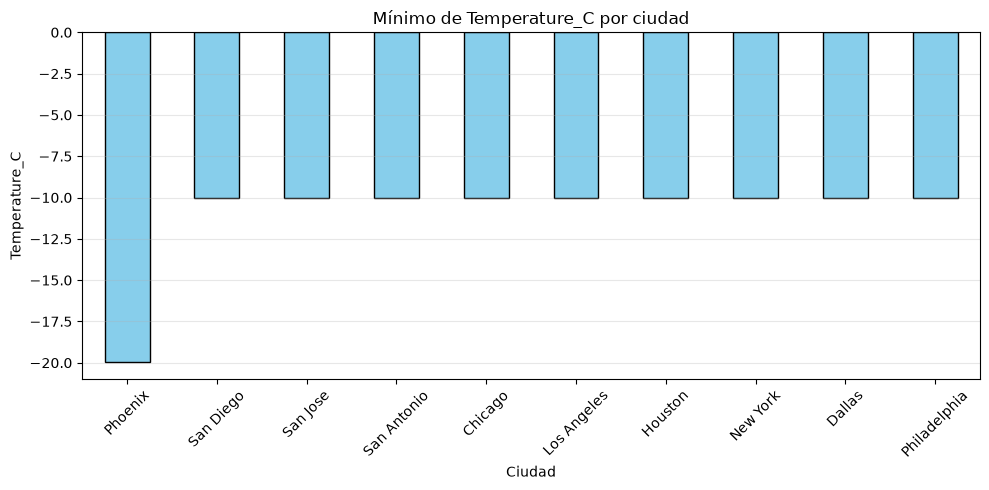

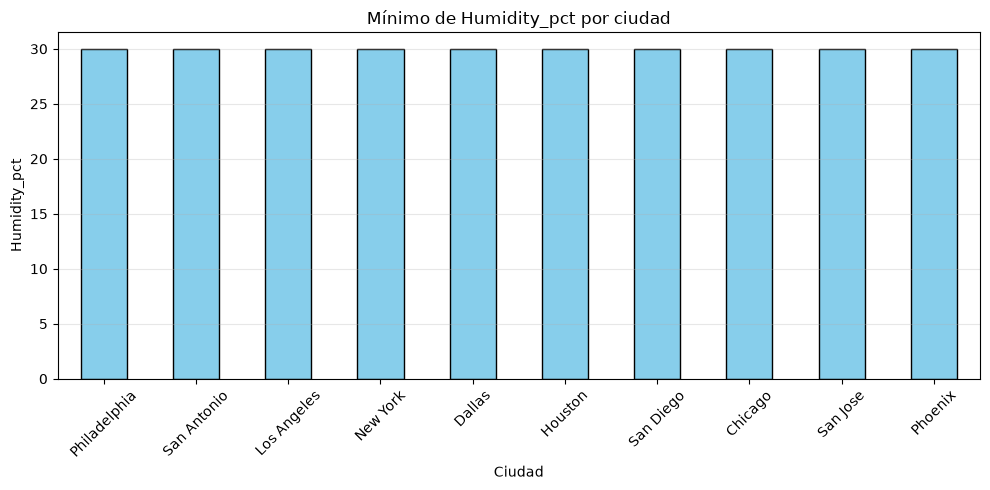

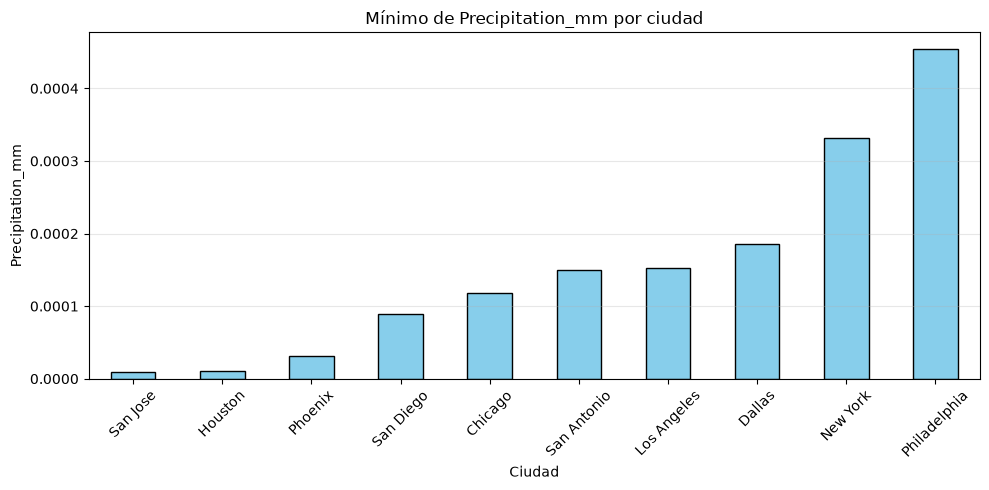

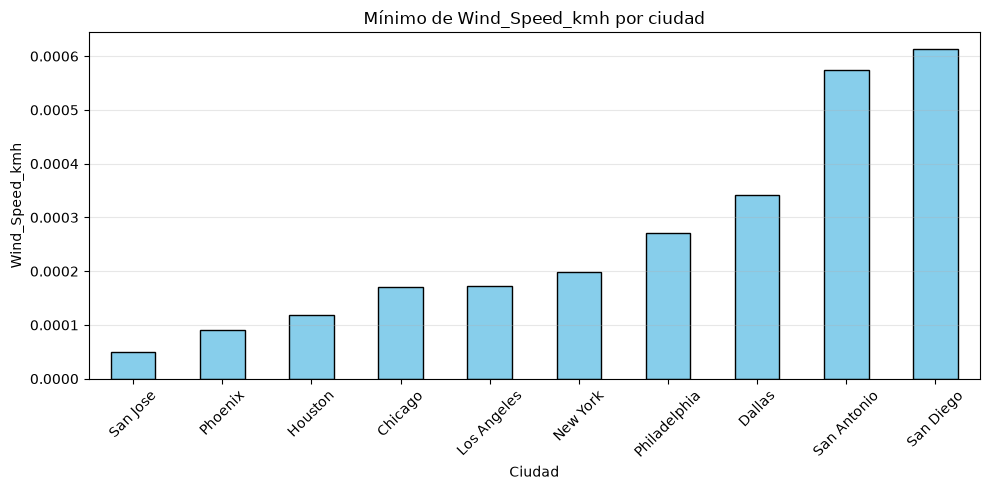

In [37]:
for variable in variables_importantes:

    datos_ciudad = df.groupby("Location")[variable].min().sort_values()

    datos_ciudad.plot(
        kind="bar",
        figsize=(10, 5),
        color="skyblue",
        edgecolor="black"
    )

    plt.title(f"Mínimo de {variable} por ciudad")
    plt.xlabel("Ciudad")
    plt.ylabel(variable)
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.5 Gráficos de mínimos mensuales por variable
Se generan gráficos de línea para identificar el valor mínimo mensual de cada variable climática importante. Para ello, se utiliza un bucle **for** que recorre la lista **variables_importantes** y repite el análisis para temperatura, humedad, precipitación y velocidad del viento.

En cada iteración, los datos se agrupan por la columna **Mes** mediante **groupby()**, y se obtiene el índice del valor mínimo con **idxmin()**. Luego, con **loc[]**, se selecciona la fila completa correspondiente a ese mínimo, incluyendo el mes, la ciudad y el valor de la variable analizada.

Finalmente, se grafica el mínimo mensual y se agrega dentro del gráfico el nombre de la ciudad asociada a cada punto, lo que permite identificar en qué ciudad ocurrió cada valor mínimo.

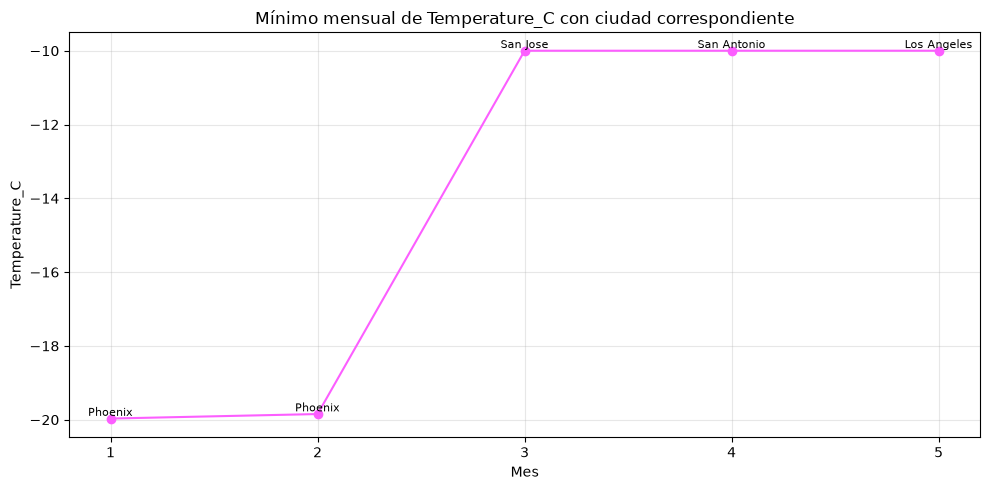

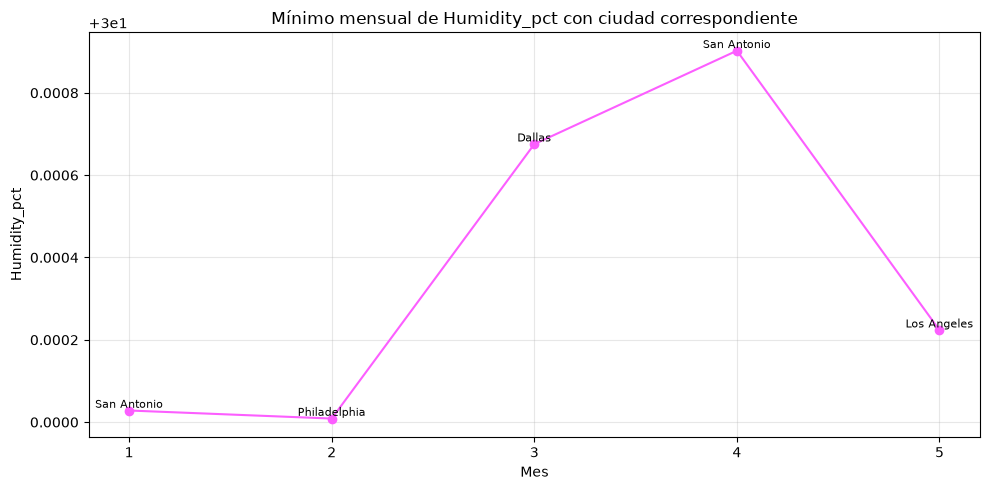

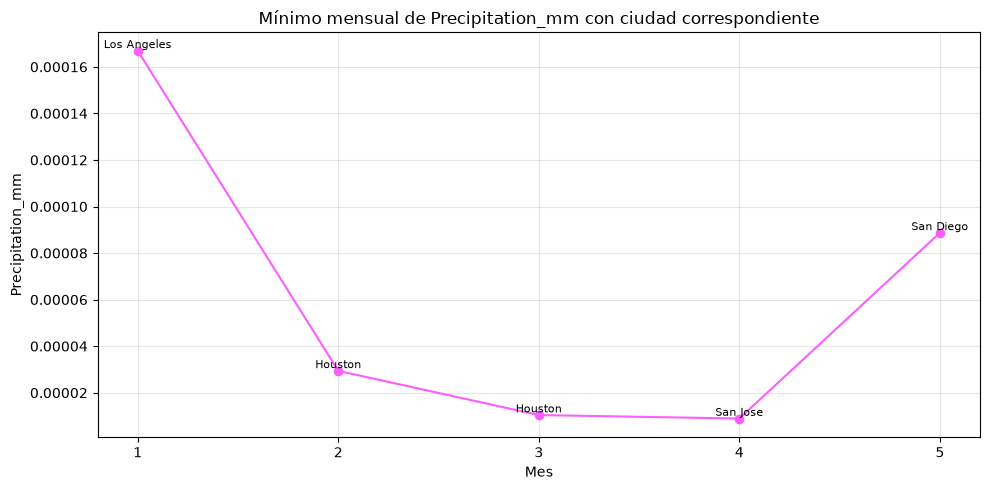

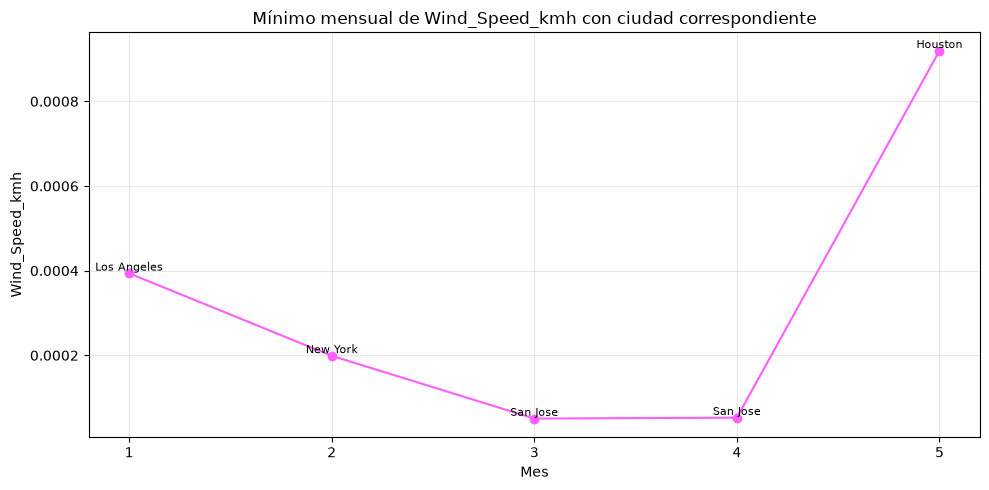

In [38]:
for variable in variables_importantes:

    indices_minimos = df.groupby("Mes")[variable].idxmin()

    datos_mes = df.loc[
        indices_minimos,
        ["Mes", "Location", variable]
    ].sort_values("Mes")

    plt.figure(figsize=(10, 5))

    plt.plot(
        datos_mes["Mes"],
        datos_mes[variable],
        marker="o",
        color="#fc5eff"
    )

    for i in range(len(datos_mes)):
        plt.text(
            datos_mes["Mes"].iloc[i],
            datos_mes[variable].iloc[i],
            datos_mes["Location"].iloc[i],
            fontsize=8,
            ha="center",
            va="bottom"
        )

    plt.title(f"Mínimo mensual de {variable} con ciudad correspondiente")
    plt.xlabel("Mes")
    plt.ylabel(variable)
    plt.xticks(datos_mes["Mes"])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.6 Gráfico de barras
**Temperatura promedio por ciudad:** Se calcula el promedio de temperatura para cada ciudad utilizando **groupby()** y **mean()**. Luego, los resultados se ordenan de mayor a menor con **sort_values()** para identificar fácilmente la ciudad con el promedio de temperatura más alto.

Además, se obtiene la ciudad con mayor promedio mediante **idxmax()** y su valor correspondiente con **max()**. Finalmente, se genera un gráfico de barras que compara la temperatura promedio por ciudad y se agregan etiquetas sobre cada barra para mostrar el valor exacto.

Ciudad con mayor promedio de temperatura: Los Angeles
Promedio de temperatura: 15.08 °C


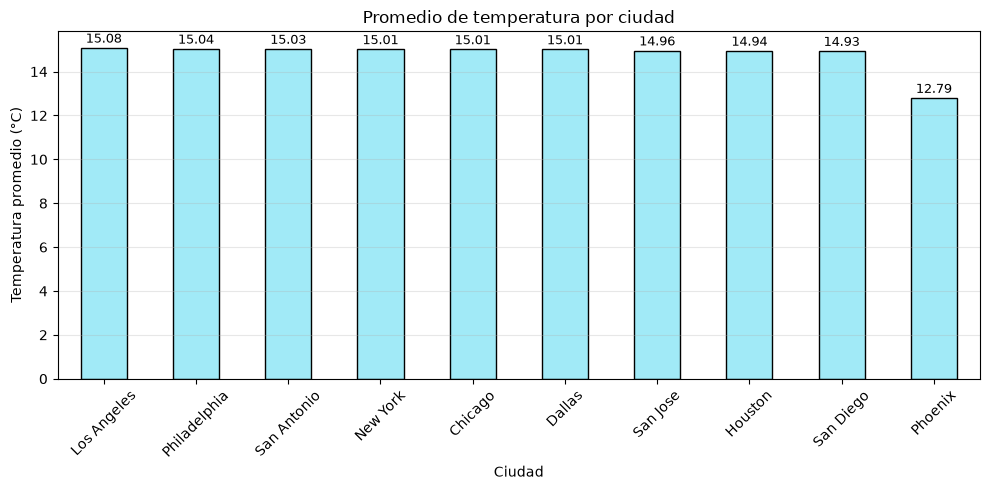

In [39]:
promedio_temperatura = df.groupby("Location")["Temperature_C"].mean().sort_values(ascending=False)

ciudad_mayor_promedio = promedio_temperatura.idxmax()
valor_mayor_promedio = promedio_temperatura.max()

print("Ciudad con mayor promedio de temperatura:", ciudad_mayor_promedio)
print("Promedio de temperatura:", round(valor_mayor_promedio, 2), "°C")

ax = promedio_temperatura.plot(
    kind="bar",
    figsize=(10, 5),
    color="#a1eaf7",
    edgecolor="black"
)

plt.title("Promedio de temperatura por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Temperatura promedio (°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for i, valor in enumerate(promedio_temperatura):
    ax.text(
        i,
        valor + 0.1,
        round(valor, 2),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Temperatura mínima y máxima por ciudad:** Se crea un gráfico de barras para comparar la temperatura mínima y máxima registrada en cada ciudad. Para ello, los datos se agrupan por **Location** y se calculan los valores mínimo y máximo de **Temperature_C** mediante **agg(["min", "max"])**.

Este gráfico permite observar el rango de temperatura de cada ciudad e identificar cuáles presentan los valores extremos más bajos y más altos.

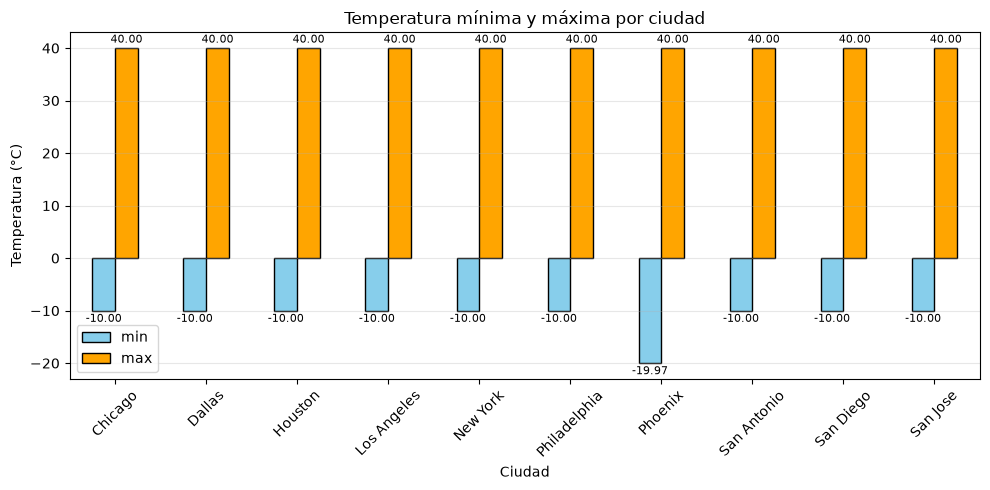

In [40]:
resumen = df.groupby("Location")["Temperature_C"].agg(["min", "max"])

ax = resumen.plot(
    kind="bar",
    figsize=(10, 5),
    color=["skyblue", "orange"],
    edgecolor="black"
)

plt.title("Temperatura mínima y máxima por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.2f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

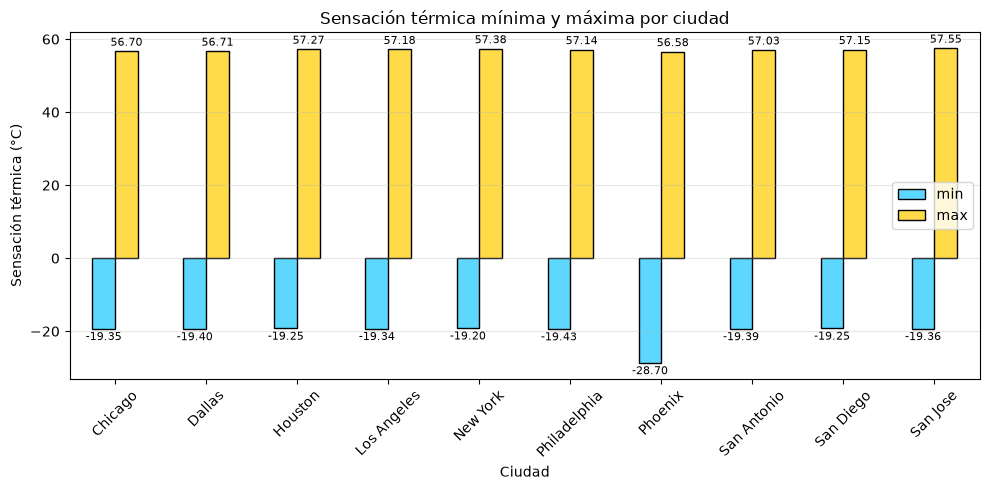

In [41]:
resumen = df.groupby("Location")["Sensacion_Termica"].agg(["min", "max"])

ax = resumen.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#5ed7ff", "#ffdb4a"],
    edgecolor="black"
)

plt.title("Sensación térmica mínima y máxima por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Sensación térmica (°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

### 4.4 Diagrama de caja y bigote por ciudad

Este diagrama de caja y bigote permite comparar la distribución de la temperatura en grados Celsius y la precipitación en mm entre las diferentes ciudades. La caja representa el rango donde se concentra la mayor parte de los datos, la línea interna muestra la mediana y los bigotes indican los valores mínimos y máximos aproximados. El gráfico ayuda a identificar qué ciudades presentan mayor variabilidad térmica y si existen diferencias importantes en el comportamiento de la temperatura entre ubicaciones.

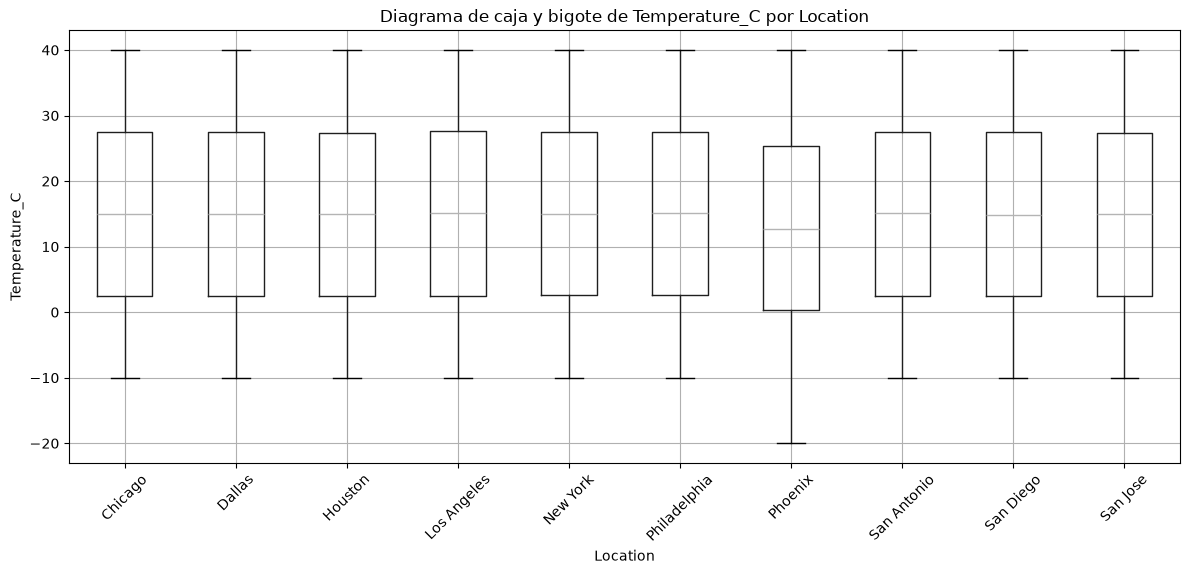

In [61]:
# Función para crear diagrama de caja y bigote
def graficar_caja_bigote(datos, columna_grupo, columna_valor):

    datos.boxplot(
        column=columna_valor,
        by=columna_grupo,
        rot=45,
        figsize=(12, 6)
    )

    plt.title(f"Diagrama de caja y bigote de {columna_valor} por {columna_grupo}")
    plt.suptitle("")
    plt.xlabel(columna_grupo)
    plt.ylabel(columna_valor)
    plt.tight_layout()
    plt.show()


graficar_caja_bigote(df, "Location", "Temperature_C")

### 4.6 Gráfico de dispersión


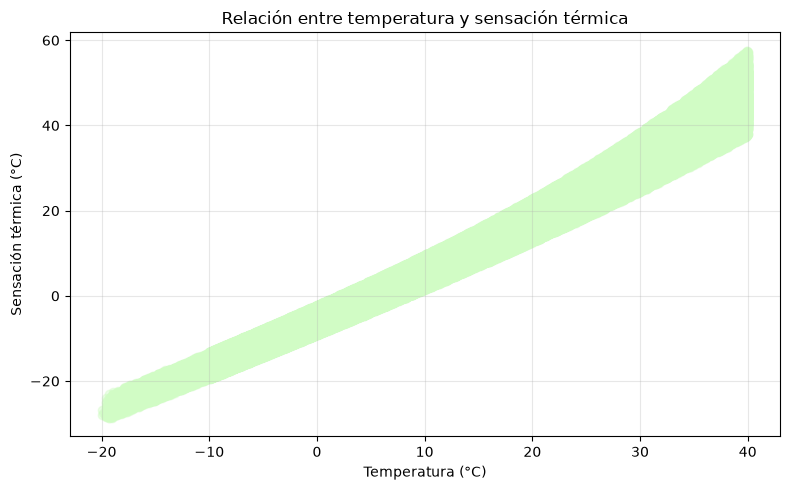

In [43]:
# Gráfico de dispersión: temperatura vs sensación térmica

# Se crea una figura para el gráfico
plt.figure(figsize=(8, 5))

# Se grafican los puntos:
# eje X = temperatura real
# eje Y = sensación térmica calculada
plt.scatter(
    df["Temperature_C"],
    df["Sensacion_Termica"],
    alpha=0.4,
    color="#d1fcc5"
)

# Se agrega el título del gráfico
plt.title("Relación entre temperatura y sensación térmica")

# Se colocan los nombres de los ejes
plt.xlabel("Temperatura (°C)")
plt.ylabel("Sensación térmica (°C)")

# Se agrega una cuadrícula para facilitar la lectura
plt.grid(True, alpha=0.3)

# Se ajusta el diseño del gráfico
plt.tight_layout()

# Se muestra el gráfico en el notebook
plt.show()


Explicación: El gráfico de dispersión muestra una relación positiva entre la temperatura y la sensación térmica. Esto significa que, a medida que aumenta la temperatura, también tiende a aumentar la sensación térmica. Sin embargo, los puntos no forman una línea exacta porque la sensación térmica también depende de otras variables climáticas, como la humedad y la velocidad del viento. Por esta razón, para una misma temperatura pueden observarse diferentes valores de sensación térmica.

### 4.7 Generación automática de gráficos por año

Como ejemplo adicional de automatización, se utiliza un bucle para generar un gráfico de precipitación mensual por cada año disponible en el conjunto de datos.


In [45]:
# Función para graficar precipitación mensual por año
def graficar_precipitacion_por_anio(datos, anio, carpeta):
    datos_anio = datos[datos["Anio"] == anio]
    precipitacion_mensual = datos_anio.groupby("Mes")["Precipitation_mm"].sum()

    plt.figure(figsize=(8, 5))
    plt.bar(precipitacion_mensual.index, precipitacion_mensual.values, color="royalblue", edgecolor="black")
    plt.title(f"Precipitación mensual total - {anio}")
    plt.xlabel("Mes")
    plt.ylabel("Precipitación total (mm)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    nombre_archivo = f"precipitacion_mensual_{anio}.png"
    ruta = os.path.join(carpeta, nombre_archivo)
    plt.savefig(ruta, dpi=150)
    plt.close()

    return ruta

# Generar un gráfico por cada año registrado
for anio in sorted(df["Anio"].dropna().unique()):
    ruta_guardada = graficar_precipitacion_por_anio(df, int(anio), carpeta_graficos)
    print("Gráfico por año guardado:", ruta_guardada)


Gráfico por año guardado: graficos_climaticos\precipitacion_mensual_2024.png


## 5. Resultados principales

En esta sección se muestran los resultados generales obtenidos después de aplicar la manipulación de datos y la visualización automatizada.


In [46]:
print("RESUMEN GENERAL DEL ANALISIS")
print("-" * 50)
print("Total de registros analizados:", len(df))
print("Total de ciudades:", df["Location"].nunique())
print("Periodo analizado:", df["Date_Time"].min(), "hasta", df["Date_Time"].max())
print("Archivo Excel generado: Weather_Data_Modificado.xlsx")
print("Carpeta de gráficos generada:", carpeta_graficos)

print("\nAnalisis especificos:")
display(analisis_especificos)


RESUMEN GENERAL DEL ANALISIS
--------------------------------------------------
Total de registros analizados: 1000000
Total de ciudades: 10
Periodo analizado: 2024-01-01 00:00:00 hasta 2024-05-18 19:44:00
Archivo Excel generado: Weather_Data_Modificado.xlsx
Carpeta de gráficos generada: graficos_climaticos

Analisis especificos:


,Analisis,Resultado,Valor
0,Mes con temperatura promedio mas alta,5,15.04
1,Anio con mayor precipitacion total,2024,5109639.13
2,Ciudad con temperatura promedio mas alta,Los Angeles,15.08
3,Ciudad con temperatura promedio mas baja,Phoenix,12.79
4,Ciudad con velocidad de viento promedio mas alta,San Diego,15.04


## 6. Conclusiones

1. Se automatizó la manipulación del conjunto de datos climáticos mediante funciones, agrupamientos, filtros y columnas derivadas.
2. Se creó la variable **Sensacion_Termica**, la cual integra temperatura, humedad y viento para ampliar el análisis climático.
3. Se aplicaron filtros avanzados para identificar registros con condiciones específicas, como temperaturas altas, humedad alta y velocidades de viento elevadas.
4. Se generaron gráficos de manera automática usando Matplotlib, incluyendo tendencias temporales, histogramas, diagramas de caja y bigote, gráficos de barras y gráficos de dispersión.
5. El DataFrame modificado fue guardado en Excel, cumpliendo con el proceso de exportación solicitado en el proyecto.
6. El análisis permitió identificar que las ciudades presentan diferencias en el comportamiento de las variables climáticas, especialmente en temperatura, precipitación, viento y sensación térmica. Estas diferencias se observaron mediante tablas de resumen, agrupamientos y gráficos comparativos.
7. Los resultados mostraron que la temperatura no debe analizarse de forma aislada, ya que la humedad y la velocidad del viento modifican la percepción térmica. Por ello, la columna derivada de **sensación térmica** permitió obtener una interpretación más completa de las condiciones climáticas.
8. Los gráficos de barras y diagramas de caja evidenciaron diferencias entre ciudades, tanto en valores promedio como en dispersión. Esto permitió reconocer qué ciudades presentaron temperaturas más altas o más bajas, así como mayor variabilidad en sus registros.
9. El análisis temporal por mes y año permitió observar patrones generales dentro del conjunto de datos. La agrupación mediante **`groupby()`** facilitó identificar los meses o años con mayores valores promedio o acumulados de variables como temperatura y precipitación.


## 7. Recomendaciones

1. Ejecutar el notebook de forma ordenada desde la primera celda hasta la última para evitar errores por variables no definidas.
2. Revisar los gráficos guardados en la carpeta **graficos_climaticos** para complementar la interpretación de los resultados.
3. Utilizar las funciones creadas para repetir el análisis con otras variables climáticas o con nuevos conjuntos de datos.
4. Verificar posibles valores atípicos antes de realizar conclusiones climáticas definitivas.


## 8. Referencias bibliográficas
- El equipo de desarrollo de Pandas. (2024). Documentación de PANDAS. https://pandas.pydata.org/docs/
- Harris, C. R., et al. (2020). Programación de matrices con NumPy. Nature, 585, 357–362. https://numpy.org/doc/
- Hunter, J. D. (2007). Matplotlib: Un entorno gráfico 2D. Computación en Ciencia e Ingeniería, 9(3), 90–95. https://matplotlib.org/stable/
- Waskom, M. L. (2021). Seaborn: visualización estadística de datos. Revista de Software de Código Abierto, 6(60), 3021. https://seaborn.pydata.org/
- Steadman, R. G. (1994). Normas de temperatura aparente en Australia. Revista Meteorológica Australiana, 43, 1–16. (Fórmula de sensación térmica adoptada por la Oficina de Meteorología de Australia).
- Material del curso: Bases de Programación, Unidades 2, 3 y 4 — Maestría en Ciencias de la Tierra.

**Link de GitHub**

https://github.com/mishelbermudesc/Bases-de-programacion_PP1.git
